In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm

OUTROOT = "/work/hdd/bdne/nchartier/Q_correction"
NREAL = 50
N_ITER = 3
figroot = "Figures"
os.makedirs(figroot, exist_ok=True)

# Plotting power spectra after Q-corrections

In [2]:
def load_pk_ratio_panel(sim, which):
    '''which: "pm", or "it1"/"it2"/"it3" for the corrected iterations.
    Returns a list of (k, ratio) tuples, one per seed, with ratio = P(k)/P_target(k)
    interpolated onto this field's own k-grid.'''
    results = []
    for seed in range(NREAL):
        d = os.path.join(OUTROOT, sim, "seed%d" % seed)
        k_nb = np.load(os.path.join(d, "k_nb.npy"))
        pk_nb = np.load(os.path.join(d, "pk_nb.npy"))

        if which == "pm":
            k_x = np.load(os.path.join(d, "k_pm.npy"))
            pk_x = np.load(os.path.join(d, "pk_pm.npy"))
        else:
            n = int(which.replace("it", ""))
            k_x = np.load(os.path.join(d, "k_corrected_it%d.npy" % n))
            pk_x = np.load(os.path.join(d, "pk_corrected_it%d.npy" % n))

        pk_nb_i = np.interp(k_x, k_nb, pk_nb)
        results.append((k_x, pk_x / pk_nb_i))
    return results





In [5]:
QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"

def load_saved_field(sim, seed, which, grid):
    '''which: "nb", "pm", or "it1"/"it2"/"it3".
    "nb" (Quijote target) now lives under quijote_lh/{seed}/, not
    Q_correction/{sim}/seed{seed}/ -- moved there by compute_quijote_products.py.'''
    if which == "nb":
        return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    return np.load(os.path.join(d, "delta_%s_grid%d.npy" % (which, grid)))


def load_pk_ratio_panel(sim, which):
    results = []
    for seed in range(NREAL):
        d = os.path.join(OUTROOT, sim, "seed%d" % seed)
        k_nb = np.load(os.path.join(QUIJOTE_ROOT, str(seed), "k.npy"))
        pk_nb = np.load(os.path.join(QUIJOTE_ROOT, str(seed), "pk.npy"))

        if which == "pm":
            k_x = np.load(os.path.join(d, "k_pm.npy"))
            pk_x = np.load(os.path.join(d, "pk_pm.npy"))
        else:
            n = int(which.replace("it", ""))
            k_x = np.load(os.path.join(d, "k_corrected_it%d.npy" % n))
            pk_x = np.load(os.path.join(d, "pk_corrected_it%d.npy" % n))

        pk_nb_i = np.interp(k_x, k_nb, pk_nb)
        results.append((k_x, pk_x / pk_nb_i))
    return results


def load_quijote_delta(seed, grid):
    '''Every seed (0-100+) now lives under this same convention, so the old
    seed<=49-vs->49 branching is gone -- that split only existed because 0-49
    used to be split across two different locations.'''
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))

def plot_pk_ratio_grid(sim, outfile=None):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True,
                              constrained_layout=True)
    cmap = cm.inferno
    norm = Normalize(vmin=0, vmax=NREAL - 1)

    panels = [
        (axes[0, 0], "pm", "PM / target"),
        (axes[0, 1], "it1", "Corrected (1 iteration) / target"),
        (axes[1, 0], "it2", "Corrected (2 iterations) / target"),
        (axes[1, 1], "it3", "Corrected (3 iterations) / target"),
    ]

    for ax, which, title in panels:
        data = load_pk_ratio_panel(sim, which)
        for seed, (k, ratio) in enumerate(data):
            ax.plot(k, ratio, color=cmap(norm(seed)), lw=1)
        ax.axhline(1.0, color="black", lw=2, ls=":")
        ax.set_xscale("log")
        ax.set_title(title, fontsize=13)
        ax.grid(alpha=0.5, color = "grey")

    fts = 15
    axes[1, 0].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=fts)
    axes[1, 1].set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=fts)
    axes[0, 0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=fts)
    axes[1, 0].set_ylabel(r"$P(k)/P_{\rm target}(k)$", fontsize=fts)

    for ax in axes.flatten():
        ax.tick_params(labelsize = 14)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.02, aspect=40)
    cbar.set_label("Seed", fontsize=fts)

    fig.suptitle(sim.upper() + " Q corrections", fontsize=18, weight = "semibold")

    if outfile is not None:
        plt.savefig(outfile, bbox_inches="tight")
    return fig, axes

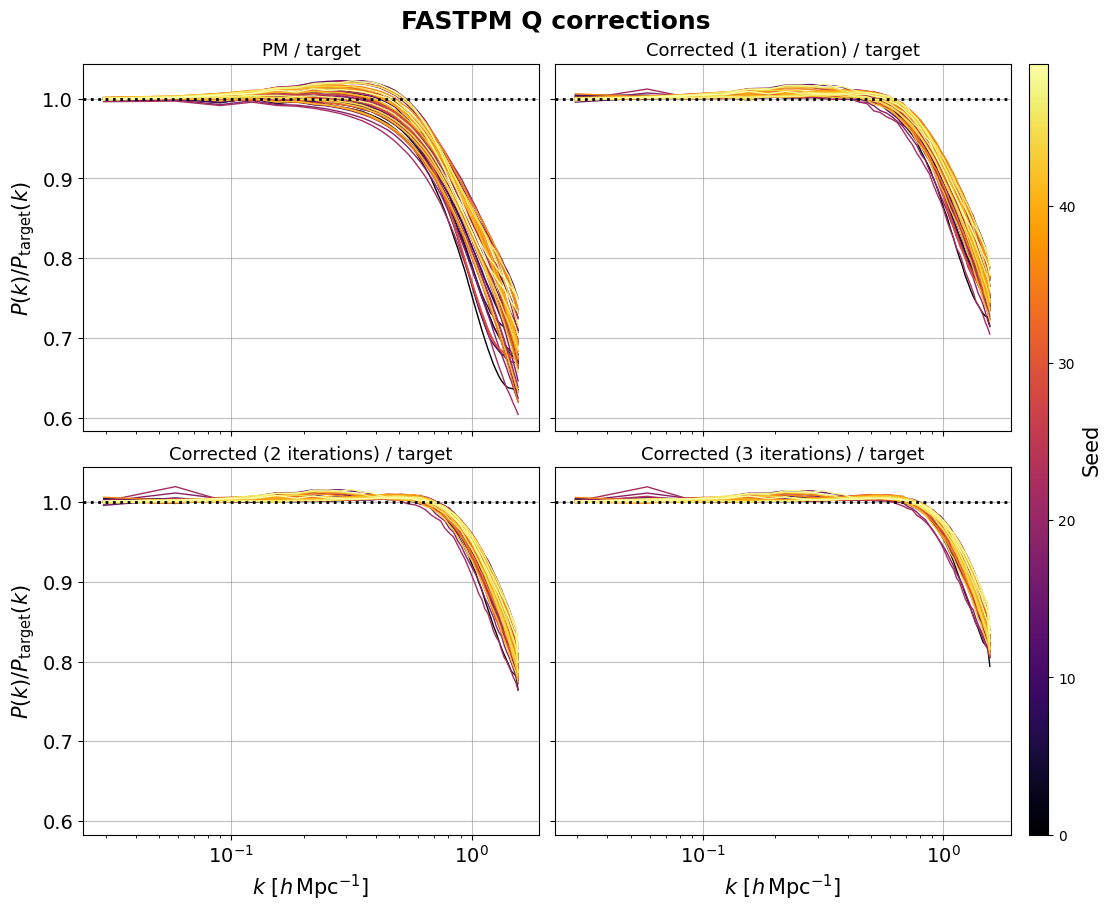

In [6]:
fig, axes = plot_pk_ratio_grid("fastpm", outfile=os.path.join(figroot, "pk_ratio_grid_fastpm.pdf"))


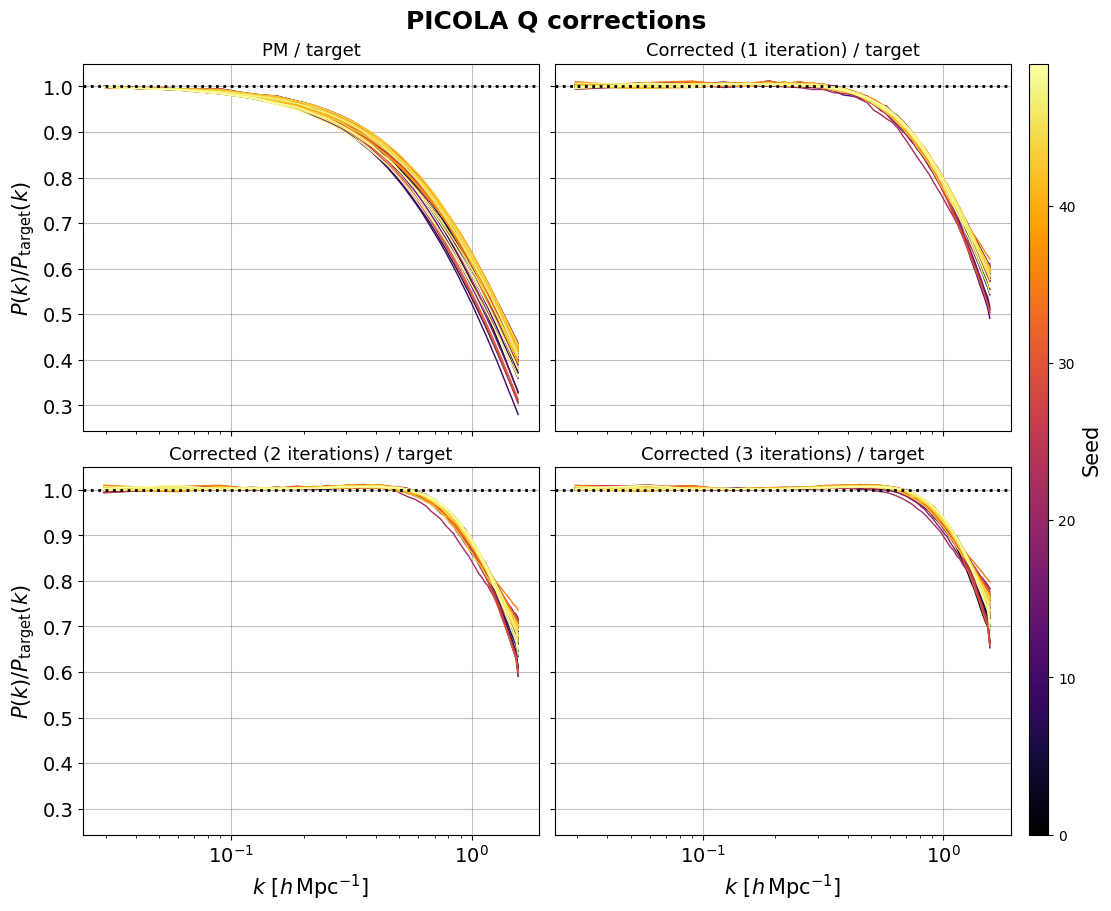

In [7]:
fig, axes = plot_pk_ratio_grid("picola", outfile=os.path.join(figroot, "pk_ratio_grid_picola.pdf"))


In [8]:
CORR_ROOT = "/work/hdd/bdne/nchartier/Q_correction"

def get_boxsize(seed):
    path = "/work/hdd/bdne/nchartier/quijote_lh/%d/snap_003" % seed
    header = readgadget.header(path)
    return header.boxsize / 1e3


def load_saved_field(sim, seed, which, grid):
    '''which: "nb", "pm", or "it1"/"it2"/"it3"'''
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    if which in ("nb", "pm"):
        fname = "delta_%s_grid%d.npy" % (which, grid)
    else:
        n = int(which.replace("it", ""))
        fname = "delta_corrected_it%d_grid%d.npy" % (n, grid)
    return np.load(os.path.join(d, fname))


def slice_2d(delta_3d, BoxSize, grid, x_min, x_max, y_min, y_max, z_min, z_max):
    '''z-averaged 2D (1+delta) slice out of a saved 3D delta grid.'''
    cell = BoxSize / grid
    ix_min, ix_max = int(round(x_min / cell)), int(round(x_max / cell))
    iy_min, iy_max = int(round(y_min / cell)), int(round(y_max / cell))
    iz_min, iz_max = int(round(z_min / cell)), int(round(z_max / cell))
    iz_max = max(iz_max, iz_min + 1)
    sub = delta_3d[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max]
    return 1.0 + sub.mean(axis=2)


In [25]:
def plot_fields_slices(fields, labels, x_min, x_max, y_min, y_max, z_min, z_max,
                        scale='log', colmap='hot', dmin=0.1, dmax=100,
                        smooth_sigma=None, figroot=None, fname='dfield_slices.pdf',
                        log_transform=False):
    '''If log_transform=True, plot log10(2+delta) = log10(1+field) on a linear
    color scale instead of the raw (1+delta) field on a log color scale
    (the dmin/dmax clip still applies in the original 1+delta units, before
    the transform, so contrast control behaves the same either way).'''
    from scipy.ndimage import gaussian_filter

    n = len(fields)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5.5),
                              sharey=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    fields = [np.clip(gaussian_filter(f, sigma=smooth_sigma) if smooth_sigma is not None else f,
                       dmin, dmax) for f in fields]

    if log_transform:
        fields = [np.log10(1.0 + f) for f in fields]  # log10(2+delta) = log10(1+(1+delta))
        norm = plt.Normalize(vmin=min(f.min() for f in fields), vmax=max(f.max() for f in fields))
    else:
        vmin = min(f.min() for f in fields)
        vmax = max(f.max() for f in fields)
        norm = LogNorm(vmin=vmin, vmax=vmax) if scale == 'log' else plt.Normalize(vmin=vmin, vmax=vmax)

    extent = [x_min, x_max, y_min, y_max]
    im = None
    for ax, field, label in zip(axes, fields, labels):
        im = ax.imshow(field.T, origin='lower', extent=extent,
                        cmap=colmap, norm=norm,
                        interpolation='sinc', aspect='equal')
        ax.set_title(label, fontsize=14)
        ax.set_xlabel(r'$x\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
    axes[0].set_ylabel(r'$y\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)

    cbar = fig.colorbar(im, ax=axes, fraction=0.05, pad=0.02, aspect=30)
    cbar.set_label(r'$\log_{10}(2+\delta)$' if log_transform else r'$1+\delta$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.suptitle(r'$z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$' % (z_min, z_max),
                  fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")
    return fig, axes

def plot_density_slices(pos_list, labels, BoxSize, grid,
                         x_min, x_max, y_min, y_max, z_min, z_max,
                         scale='log', colmap='hot', dmin=0.1, dmax=100,
                         smooth_sigma=None, figroot=None,
                         fname='dfield_slices.pdf'):
    '''Original position-based version, now just a thin wrapper.'''
    fields = [compute_density_slice_2d(pos, BoxSize, grid,
                                        x_min, x_max, y_min, y_max, z_min, z_max)
              for pos in pos_list]
    return plot_fields_slices(fields, labels, x_min, x_max, y_min, y_max, z_min, z_max,
                               scale=scale, colmap=colmap, dmin=dmin, dmax=dmax,
                               smooth_sigma=smooth_sigma, figroot=figroot, fname=fname)



In [26]:
import readgadget
import bigfile

def load_quijote(seed):
    path = "/work/hdd/bdne/nchartier/quijote_lh/%d/snap_003" % seed
    header = readgadget.header(path)
    BoxSize = header.boxsize / 1e3
    pos = readgadget.read_block(path, "POS ", [1]) / 1e3
    return pos, BoxSize

def load_fastpm(seed):
    path = "/work/hdd/bdne/maho3/cmass-ili/quijotelike_for_nicolas/fastpm/L1000-N128/%d/fastpm_B2_0.6667" % seed
    infile = bigfile.File(path)
    return infile['1/Position'][:]

def load_lpicola(seed):
    path = "/work/hdd/bdne/nchartier/cola_lh/%d/Cola%d_512_20stepsnLPTpos0p5_z0p500" % (seed, seed)
    return readgadget.read_block(path, "POS ", [1]) / 1e3


In [27]:
QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"

def load_quijote_delta(seed, grid):
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))


def load_saved_field(sim, seed, which, grid):
    '''which: "pm" or "it1"/"it2"/"it3" -- picola/fastpm fields, still under
    Q_correction/. Filenames aren't uniform: "pm" has no "corrected_" prefix,
    but the iteration fields do (delta_corrected_it{n}_grid{g}.npy).'''
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    if which == "pm":
        fname = "delta_pm_grid%d.npy" % grid
    else:
        fname = "delta_corrected_%s_grid%d.npy" % (which, grid)
    return np.load(os.path.join(d, fname))

def plot_stage_comparison(seed, stage, grid=512,
                           x_min=0., x_max=600., y_min=0., y_max=600.,
                           z_min=490., z_max=510.,
                           dmin=0.9, dmax=80, smooth_sigma=1.0,
                           figroot=figroot, log_transform=False):
    if stage not in (0, 1, 2, 3):
        raise ValueError("stage must be 0, 1, 2, or 3, got %r" % stage)

    which = "pm" if stage == 0 else "it%d" % stage
    stage_label = "initial" if stage == 0 else "%d correction%s" % (stage, "s" if stage > 1 else "")

    BoxSize = get_boxsize(seed)

    field_nb = load_quijote_delta(seed, grid)
    field_picola = load_saved_field("picola", seed, which, grid)
    field_fastpm = load_saved_field("fastpm", seed, which, grid)

    fields_2d = [slice_2d(f, BoxSize, grid, x_min, x_max, y_min, y_max, z_min, z_max)
                 for f in (field_nb, field_picola, field_fastpm)]

    fig, axes = plot_fields_slices(
        fields_2d,
        ["Quijote (target)", "L-PICOLA (%s)" % stage_label, "FastPM (%s)" % stage_label],
        x_min, x_max, y_min, y_max, z_min, z_max,
        scale='log', colmap='hot', dmin=dmin, dmax=dmax,
        smooth_sigma=smooth_sigma, figroot=None, log_transform=log_transform)

    fig.suptitle(r'seed %d, %s ($z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$)' %
                 (seed, stage_label, z_min, z_max), fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        fname = "dfield_slices_seed%d_stage%d.pdf" % (seed, stage)
        plt.savefig(os.path.join(figroot, fname), bbox_inches="tight")

    return fig, axes


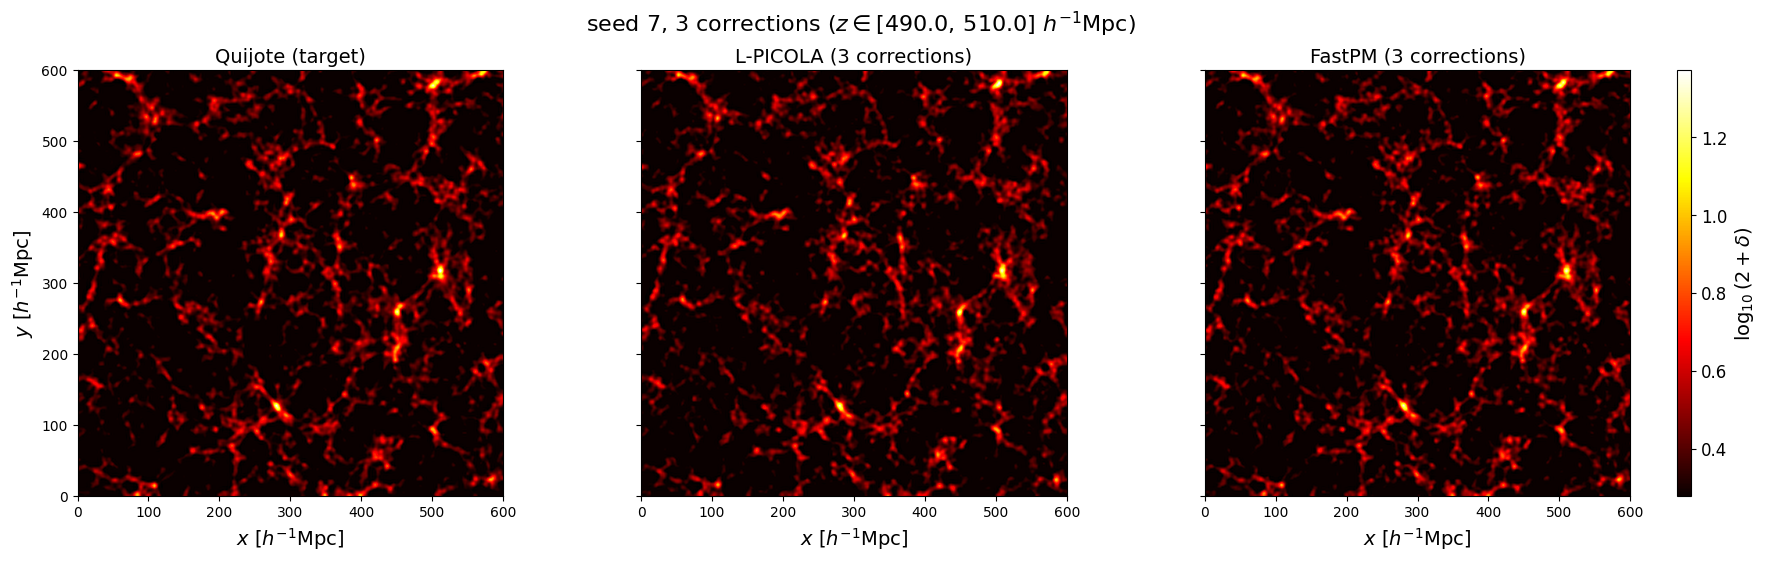

In [31]:
fig, axes = plot_stage_comparison(seed=7, stage=3, log_transform = True)

# Trying PQMass

## 2d tests

## 3d tests

In [32]:
from pqm import pqm_chi2

QUIJOTE_ROOT = "/work/hdd/bdne/nchartier/quijote_lh"
CORR_ROOT = "/work/hdd/bdne/nchartier/Q_correction"

def load_quijote_delta(seed, grid):
    return np.load(os.path.join(QUIJOTE_ROOT, str(seed), "delta_grid%d.npy" % grid))

def load_saved_field(sim, seed, which, grid):
    d = os.path.join(CORR_ROOT, sim, "seed%d" % seed)
    if which == "pm":
        fname = "delta_pm_grid%d.npy" % grid
    else:
        fname = "delta_corrected_%s_grid%d.npy" % (which, grid)
    return np.load(os.path.join(d, fname))

def downsample_3d(field_3d, factor):
    nz, ny, nx = field_3d.shape
    nz_trim = (nz // factor) * factor
    ny_trim = (ny // factor) * factor
    nx_trim = (nx // factor) * factor
    trimmed = field_3d[:nz_trim, :ny_trim, :nx_trim]
    return trimmed.reshape(nz_trim // factor, factor,
                            ny_trim // factor, factor,
                            nx_trim // factor, factor).mean(axis=(1, 3, 5))

def quick_hub_check(x, y, num_refs=25, seed=0):
    from pqm.utils import _sample_reference_indices_numpy, _compute_counts_numpy
    Nx = num_refs // 2
    Ny = num_refs - Nx
    np.random.seed(seed)
    refs, x_rem, y_rem = _sample_reference_indices_numpy(Nx, Ny, 0, x.copy(), y.copy())
    counts_x, counts_y = _compute_counts_numpy(x_rem, y_rem, refs, num_refs, kernel="euclidean")
    n_filled = ((counts_x > 0) | (counts_y > 0)).sum()
    top_bin_frac = max(counts_x.max(), counts_y.max()) / (counts_x.sum() + counts_y.sum())
    print(f"  filled bins: {n_filled}/{num_refs}, top bin holds {top_bin_frac:.1%} of samples")
    return counts_x, counts_y

grid = 512
downsample_factor = 256  # -> 2^3 = 8 dims, our validated safe starting point

quijote_seeds = range(0, 101)  # adjust to whatever range you've actually confirmed complete

def build_x(sim, stage, factor):
    which = "pm" if stage == 0 else "it%d" % stage
    fields = []
    for seed in range(0, 50):
        delta_3d = load_saved_field(sim, seed, which, grid)
        fields.append(downsample_3d(delta_3d, factor).ravel())
    return np.stack(fields)

def build_y(seeds, factor):
    fields = []
    for seed in seeds:
        delta_3d = load_quijote_delta(seed, grid)
        fields.append(downsample_3d(delta_3d, factor).ravel())
    return np.stack(fields)

## PQMass field-level test — 3D, downsampled

**summary with the help of a LLM**

**What this tests:** whether the distribution of L-PICOLA/FastPM density fields
(50 realizations, drawn from the Latin Hypercube) is statistically distinguishable
from the distribution of Quijote (target) density fields. 


**Why downsample:** PQMass needs a Voronoi tessellation of the sample space to
work reliably, and with only `~50`-`100` realizations per side, the raw field
(`256³`/`512³` ≈ millions of dimensions) is far too high-dimensional for that —
we hit this directly earlier as a `ValueError`/warning from PQMass itself
("Only one Voronoi cell has samples")
`downsample_3d` block-averages the field down to a much coarser grid
(`factor=256` on a `grid=512` field → `2×2×2=8` dimensions) before flattening,
trading spatial resolution for statistical reliability.

**`quick_hub_check` output** (`filled bins: X/num_refs, top bin holds Y%`):
a cheap, single-draw diagnostic before running the full (expensive,
`re_tessellation=1000`) test. `num_refs` reference points are drawn from `x`
and `y` combined; every remaining sample is assigned to its nearest reference,
and we check how evenly those assignments spread across bins. Close to
`num_refs` filled bins and a low top-bin percentage means the space is well
partitioned; few filled bins or one dominant bin means the result would be
unreliable or would error outright.

**The final `pqm_chi2` output** (`mean`, `std` printed): `re_tessellation=1000`
repeats the test with different random reference points each time, giving a
distribution of `χ²_PQM` values. Under the null hypothesis (same underlying
distribution) this should follow a `χ²` distribution with `dof = num_refs - 1`
— mean `≈ dof`, std `≈ √(2·dof)`. A mean well above `dof` (with a std in the
right ballpark, not anomalously small) indicates the two sets are
distinguishable — i.e. picola/fastpm's field distribution measurably differs
from Quijote's at whatever spatial scale this downsampling still resolves.

In [33]:
x = build_x("picola", stage=0, factor=downsample_factor)
y = build_y(quijote_seeds, factor=downsample_factor)
print("x shape:", x.shape, " y shape:", y.shape)

x shape: (50, 8)  y shape: (101, 8)


In [34]:
quick_hub_check(x, y, num_refs=25)

  filled bins: 24/25, top bin holds 10.3% of samples


(array([2, 2, 0, 0, 0, 0, 1, 4, 0, 0, 3, 0, 2, 2, 3, 5, 1, 1, 2, 0, 1, 1,
        4, 1, 3]),
 array([ 4,  9,  4,  4,  2,  2,  2, 12,  1,  1,  7,  2,  1,  1,  3, 13,  1,
         1,  1,  0,  2,  0,  7,  0,  8]))

**PQMASS errors and warning notes**

- UserWarning (from pqm.pqm._pqm_test, pqm/pqm.py:172-175):Less than half of the Voronoi cells have any samples in them.
Possibly due to a small number of samples or a pathological
distribution. Result may be unreliable. If possible, increase the
number of x_samples and y_samples. [Context: first field-level test, 2D slices (~1444 dims after downsampling), num_refs=20, N_x=N_y=50 (picola vs. Quijote).]
- ValueError (from pqm.pqm._pqm_test, pqm/pqm.py:163-171):Only one Voronoi cell has samples, so chi^2 cannot 
be computed. This is likely due to a small number 
of samples or a pathological distribution. If possible, 
increase the number of x_samples and y_samples. [Context: hit this one twice — Quijote null test with a 25-vs-25 split of the same 50 realizations at num_refs=10, and again on the independent 50-vs-50 Quijote null test (original 0-49 vs. new 51-100) at num_refs=25. Both are field-level (2D slice) tests.]